In [7]:
from pathlib import Path
import sys

_REPO_ROOT_CANDIDATES = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next((path for path in _REPO_ROOT_CANDIDATES if (path / "src").is_dir()), Path.cwd())
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
FIGS_ROOT = REPO_ROOT / "figs"
for _path in (REPO_ROOT, NOTEBOOKS_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import numpy as np
import torch, json
import torch.nn as nn
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt
from scipy.optimize import brentq
from pathlib import Path
from src.models import BinaryClassifier
import utils
plt.rc('axes', prop_cycle=plt.cycler(color=plt.get_cmap('Set1').colors))

In [14]:
config_ids = ["007"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)

models, priors = {}, {}
for config_id in config_ids:
    models[config_id] = {}
    config_path = FIGS_ROOT / f"config_{config_id}" / "config.json"
    with open(config_path, 'r') as f:
        config = json.load(f)
    model_path = FIGS_ROOT / f"config_{config_id}" / "models"
    for folder in Path(model_path).iterdir():
        if folder.is_dir():
            folder_key = int(folder.name.split('_')[-1])
            models[folder_key] = {}
            for file in folder.iterdir():
                if file.suffix == '.pth':
                    model = BinaryClassifier(config)
                    model.load_state_dict(torch.load(file))
                    model_key = file.stem.split('_')[1]
                    models[folder_key][model_key] = model

    priors[config_id] = {
        prior_fct.__name__: utils.normalize(np.vectorize(prior_fct), *config["data"]["parameter_range"]) for prior_fct in [
            utils.uniform, utils.normal, utils.exponential, utils.gamma, utils.sinusoidal
        ]
    }

KeyError: 'parameter_range'

In [9]:
def compute_ratio(data, parameter, model):
    def _to_array_or_scalar(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if np.isscalar(x):
            return x, 'scalar'
        x = np.asarray(x)
        assert x.ndim == 1, "Expected 1D input when passing an array-like."
        return x, 'vector'

    data_point, _t_data = _to_array_or_scalar(data)
    parameters, _t_param = _to_array_or_scalar(parameter)

    if _t_data == 'scalar' and _t_param == 'vector':
        data_point = np.full(parameters.shape, data_point, dtype=float)
    elif _t_data == 'vector' and _t_param == 'scalar':
        parameters = np.full(data_point.shape, parameters, dtype=float)
    elif _t_data == 'vector' and _t_param == 'vector':
        assert len(data_point) == len(parameters), "data and parameter must have the same length."
    elif _t_data == 'scalar' and _t_param == 'scalar':
        data_point = [data_point]
        parameters = [parameter]
    
    model_in = torch.cat(
        tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_point, parameters)],
        dim=1
    )
    model_out = model(model_in).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    return ratio, model_out

def reweight_distributions(test_parameters, n_test_data=int(1e6), n_bins=int(1e3)):
    all_ratios = {}
    all_outs = {}
    reweighting_distributions = {}
    reweighted_distributions = {}
    data_x = [generator.normal(loc=parameter, scale=config["data"]["std"], size=n_test_data) for parameter in test_parameters]
    for prior, model in zip(priors, models[0]):
        results = [compute_ratio(data_x[0], parameter, model) for parameter in test_parameters]
        ratios = [result[0] for result in results]
        model_outs = [result[1] for result in results]
        all_ratios[prior.__name__] = ratios
        all_outs[prior.__name__] = model_outs
        reweighting_distributions[prior.__name__] = ratios[1] / ratios[0]
        reweighted_distribution, edges = np.histogram(
            data_x[0],
            bins=n_bins,
            weights=reweighting_distributions[prior.__name__],
            density=True,
            range=config["data"]["parameter_range"]
        )
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        reweighted_distributions[prior.__name__] = (bin_centers, reweighted_distribution)
    return data_x, reweighted_distributions, reweighting_distributions, all_outs

KeyError: '007'

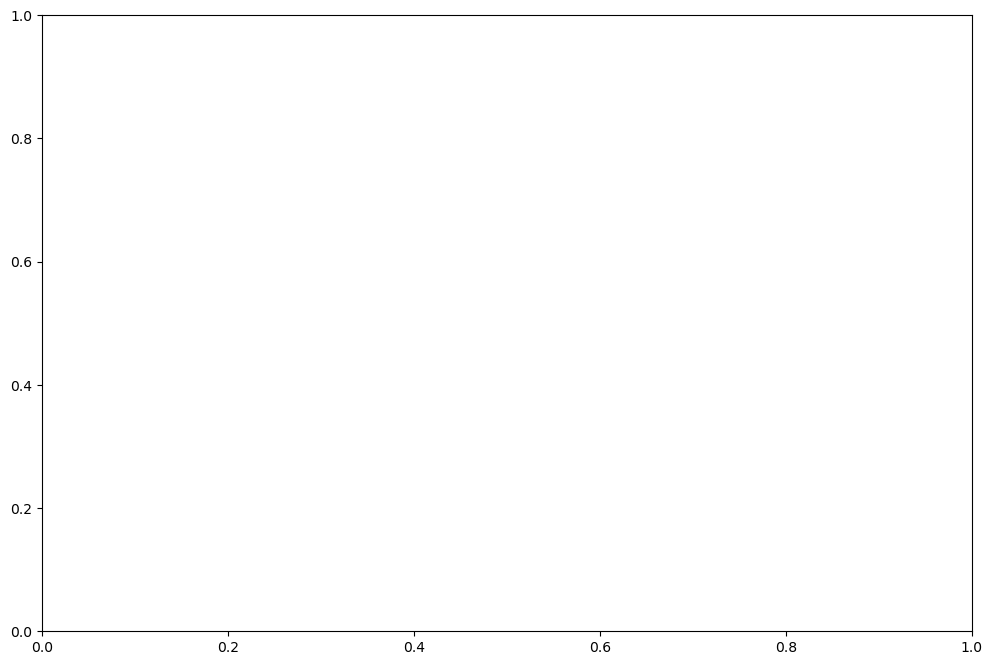

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))
model_iteration = 0
auc_configs = ["007"]

for config_id in auc_configs:
    for prior_name in priors[config_id].keys():
        prior_func = priors[config_id][prior_name]
        
        # Generate test data for this prior
        _, _, (data_test, parameters_test, labels_test) = utils.get_data(prior_func, config, show_output=False)
        
        # Prepare test data
        X_test = torch.stack([data_test, parameters_test], dim=1).numpy()
        y_test = labels_test.numpy()
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        
        # Get the corresponding model (using the last iteration, model_idx=4)
        if prior_name in models[model_iteration]:
            model = models[model_iteration][prior_name].to(device)
            model.eval()
            
            # Get predictions
            with torch.no_grad():
                y_pred = model(X_test_tensor).cpu().numpy().flatten()
            
            # Compute ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_pred)
            auc = roc_auc_score(y_test, y_pred)
            
            # Plot
            ax.plot(fpr, tpr, label=f'{prior_name} (AUC = {auc:.3f})', linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1.5)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves for Different Priors', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.show()

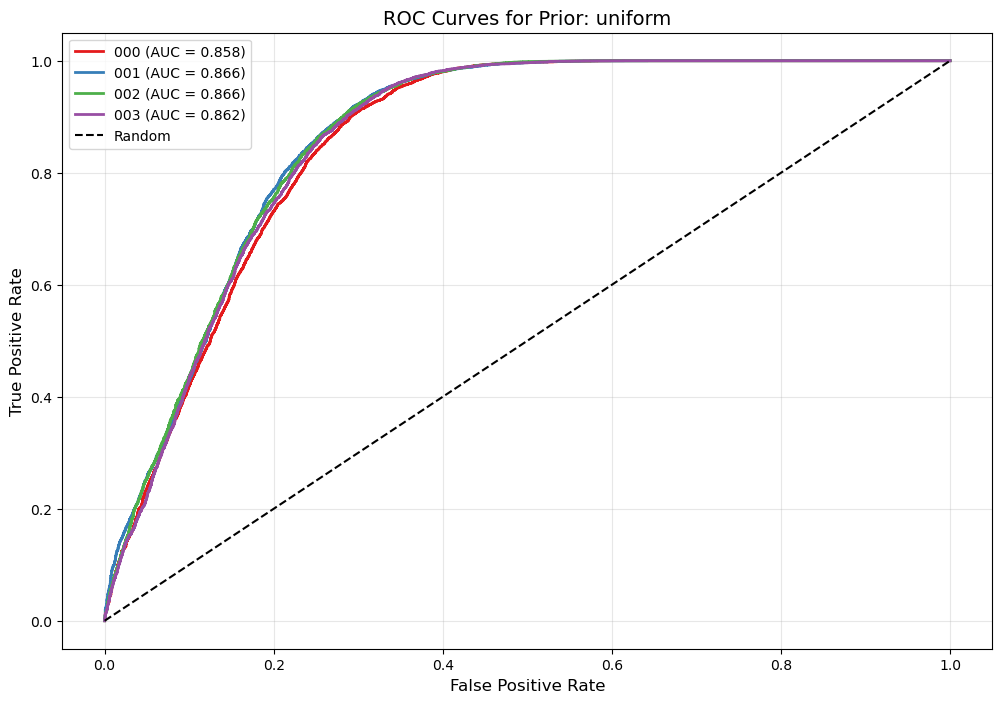

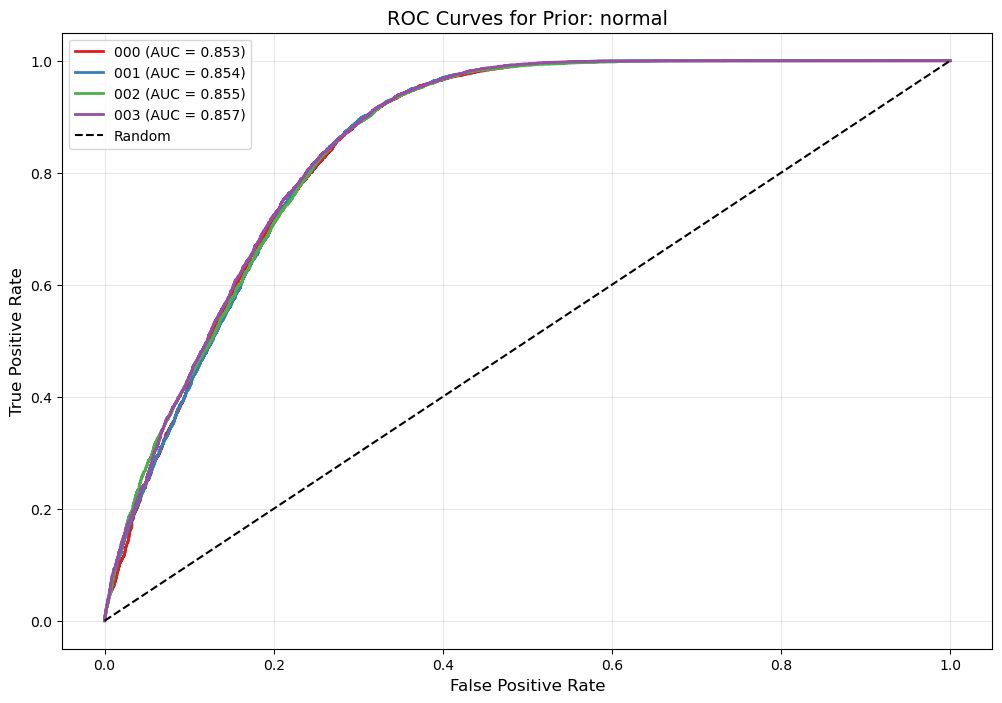

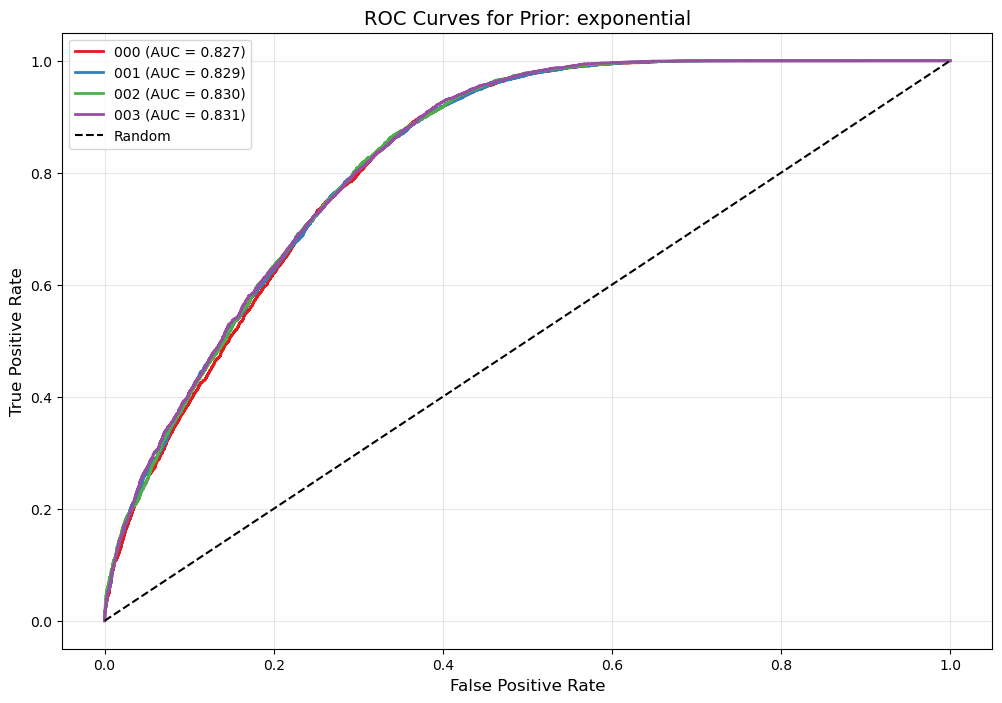

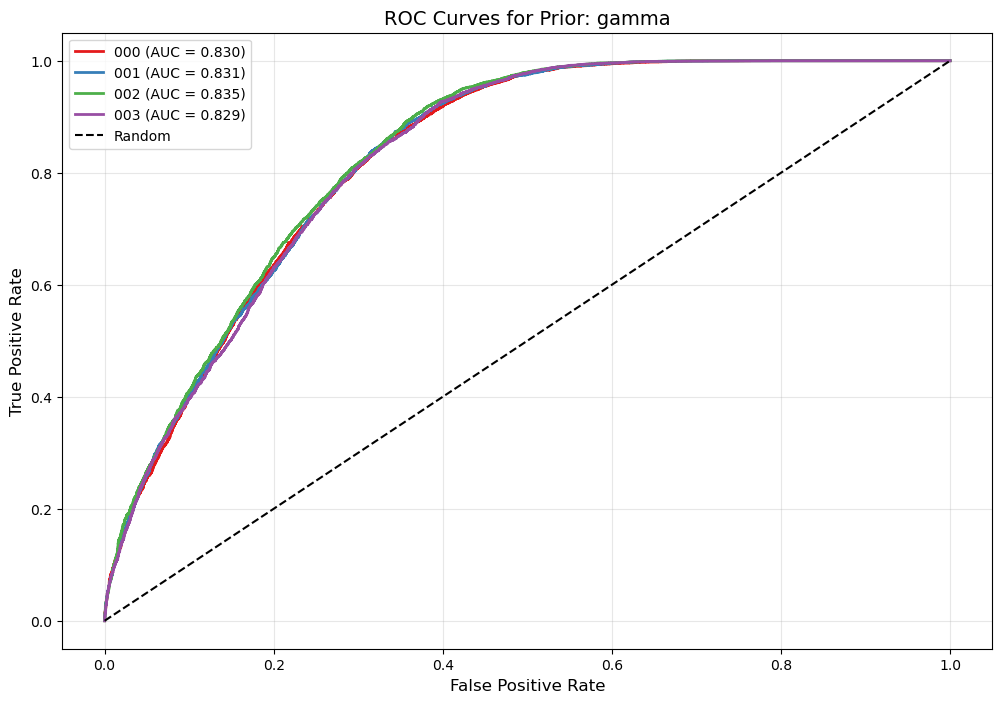

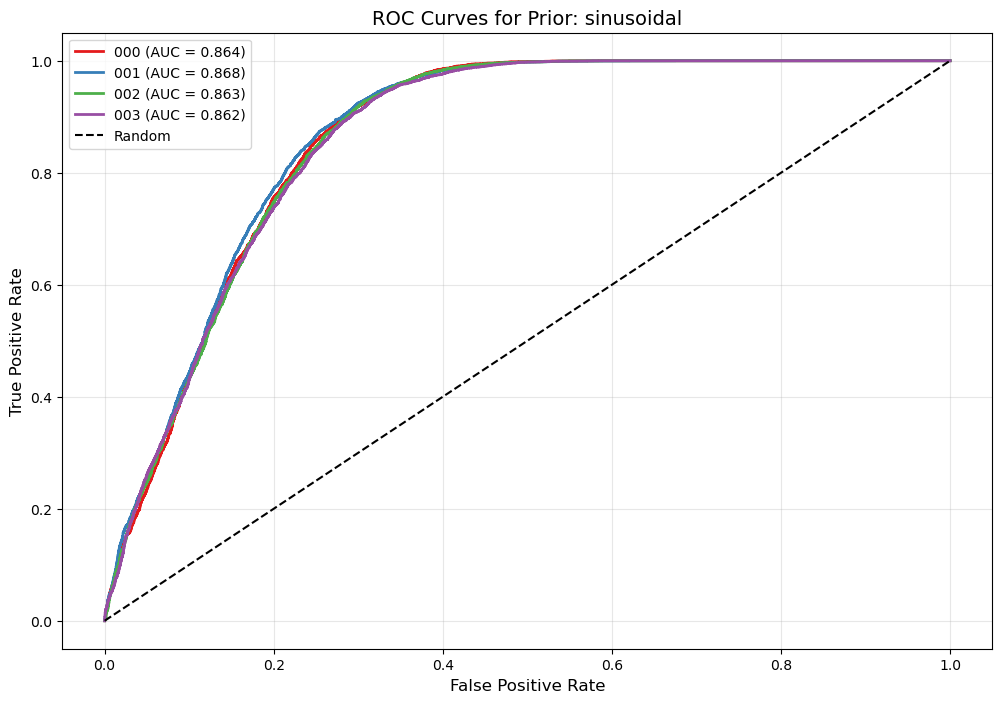

In [12]:
auc_configs = ["000", "001", "002", "003"]
for prior_name in priors[auc_configs[0]].keys():
    fig, ax = plt.subplots(figsize=(12, 8))

    for config_id in auc_configs:
        with open(FIGS_ROOT / f"config_{config_id}" / "config.json", 'r') as f:
            cfg = json.load(f)

        prior_func = priors[config_id][prior_name]
        _, _, (data_test, parameters_test, labels_test) = utils.get_data(prior_func, cfg, show_output=False)

        X_test = torch.stack([data_test, parameters_test], dim=1).numpy()
        y_test = labels_test.numpy()
        X_test_tensor = torch.FloatTensor(X_test).to(device)

        # search recursively for model files (handles models_0/ subdirs)
        model_dir = FIGS_ROOT / f"config_{config_id}" / "models"
        candidate_files = [fp for fp in model_dir.rglob("*.pth") if fp.stem.split('_')[1] == prior_name]
        if not candidate_files:
            continue
        latest_model_file = sorted(candidate_files)[-1]

        model = BinaryClassifier(cfg).to(device)
        model.load_state_dict(torch.load(latest_model_file))
        model.eval()

        with torch.no_grad():
            y_pred = model(X_test_tensor).cpu().numpy().flatten()

        fpr, tpr, _ = roc_curve(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)
        ax.plot(fpr, tpr, label=f'{config_id} (AUC = {auc:.3f})', linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1.5)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curves for Prior: {prior_name}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.show()